In [2]:
import pandas as pd

In [3]:
df=pd.read_csv("../datasets/diabetes.csv")

In [4]:
df.shape

(768, 9)

In [5]:
df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [7]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [8]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [9]:
# Check zero values in important columns
zero_columns = ['Glucose', 'BloodPressure', 
                'SkinThickness', 'Insulin', 'BMI']

print("Zero Values Count:")
for col in zero_columns:
    zeros = (df[col] == 0).sum()
    percentage = (zeros/len(df))*100
    print(f"{col}: {zeros} zeros ({percentage:.1f}%)")

Zero Values Count:
Glucose: 5 zeros (0.7%)
BloodPressure: 35 zeros (4.6%)
SkinThickness: 227 zeros (29.6%)
Insulin: 374 zeros (48.7%)
BMI: 11 zeros (1.4%)


In [10]:
df.duplicated().sum()

0

In [11]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [12]:
df.tail()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1
767,1,93,70,31,0,30.4,0.315,23,0


In [13]:
print(df['Outcome'].value_counts())

Outcome
0    500
1    268
Name: count, dtype: int64


In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

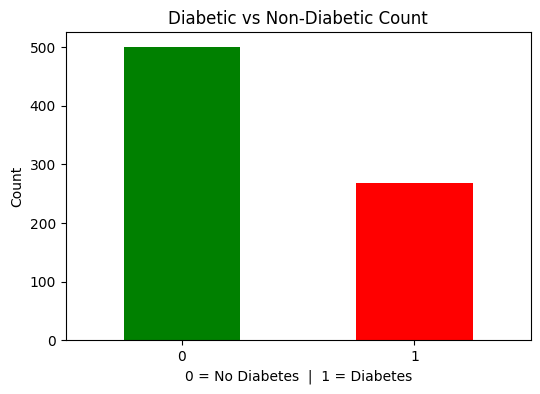

In [15]:
plt.figure(figsize=(6,4))
df["Outcome"].value_counts().plot(kind='bar',color=['green','red'])
plt.title('Diabetic vs Non-Diabetic Count')
plt.xlabel('0 = No Diabetes  |  1 = Diabetes')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

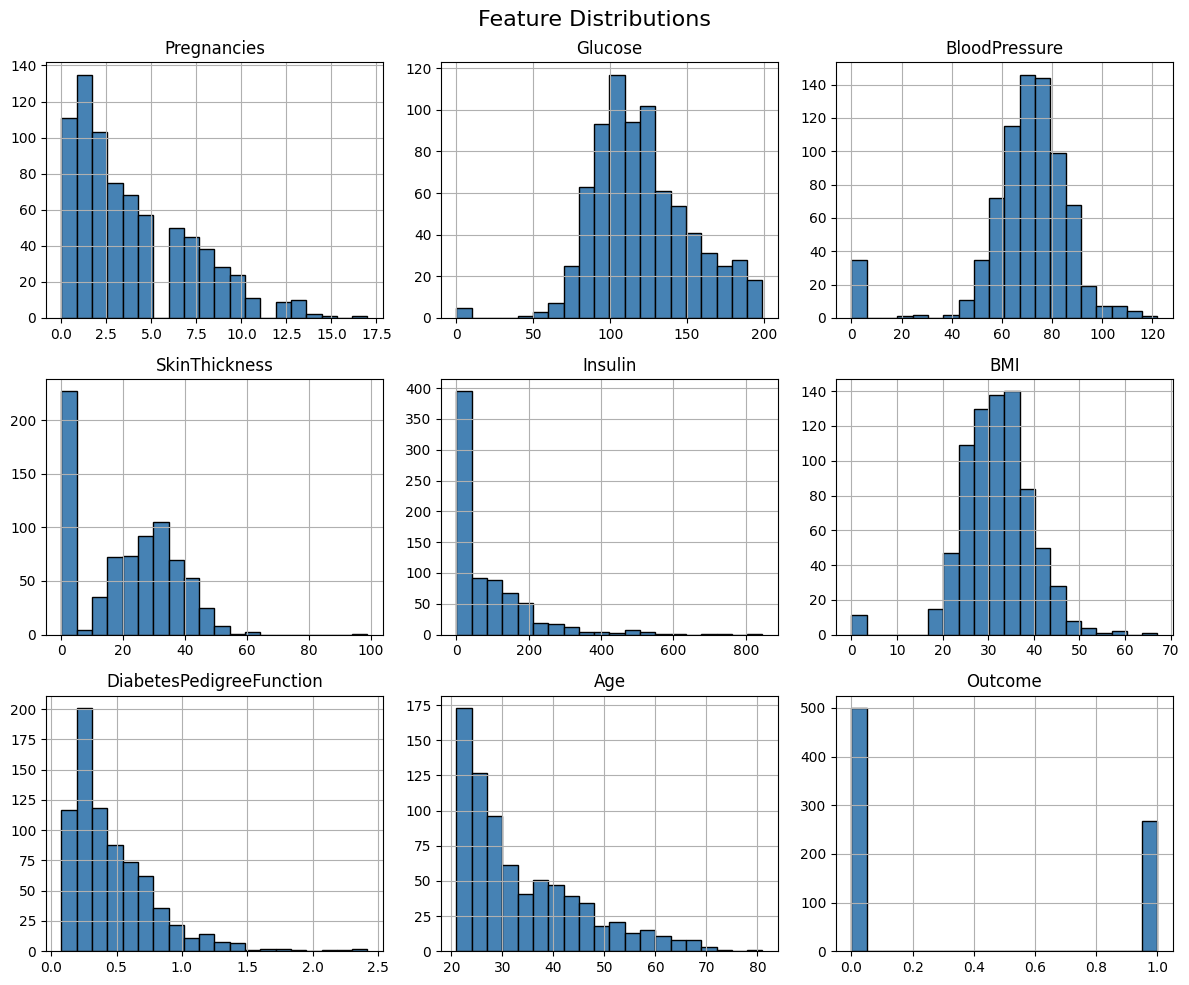

In [16]:
df.hist(figsize=(12,10), bins=20, 
        color='steelblue', edgecolor='black')
plt.suptitle('Feature Distributions', fontsize=16)
plt.tight_layout()
plt.show()

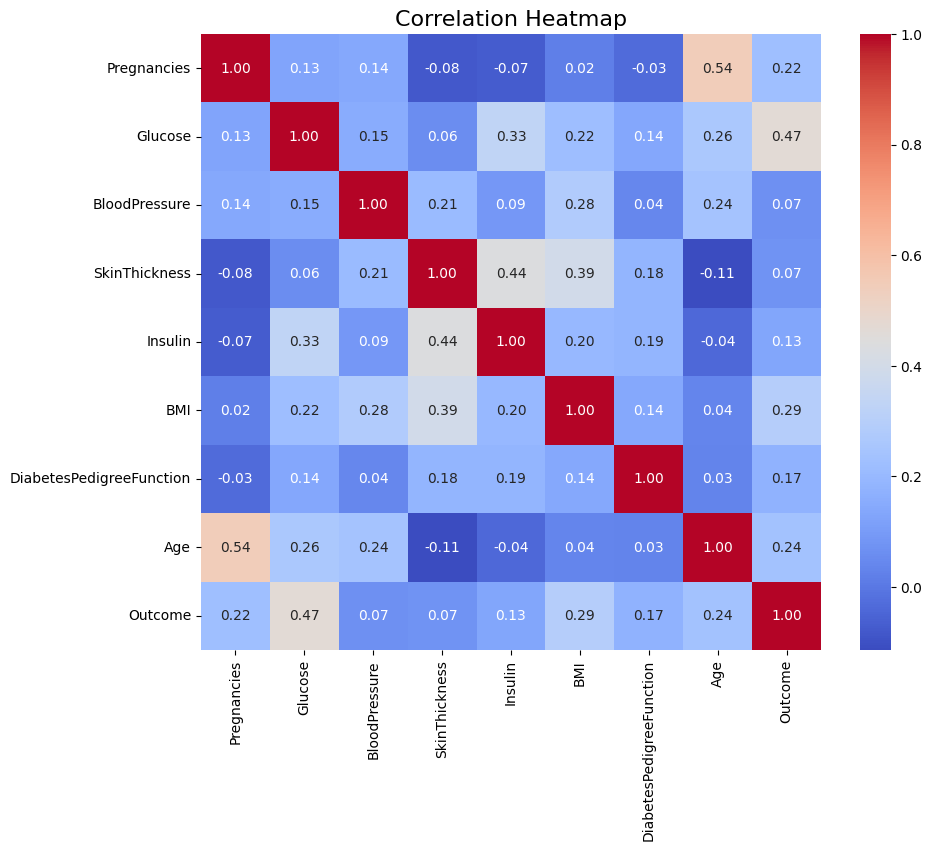

In [17]:
# Correlation Heatmap
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, 
            fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap', fontsize=16)
plt.show()

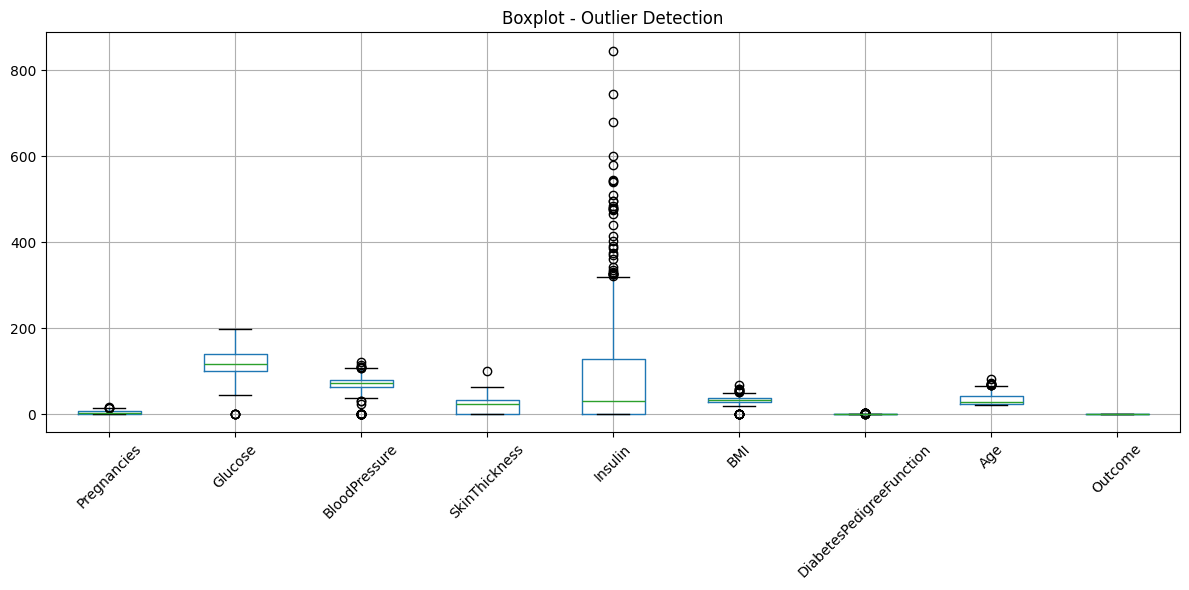

In [18]:
# Boxplot
plt.figure(figsize=(12,6))
df.boxplot()
plt.xticks(rotation=45)
plt.title('Boxplot - Outlier Detection')
plt.tight_layout()
plt.show()

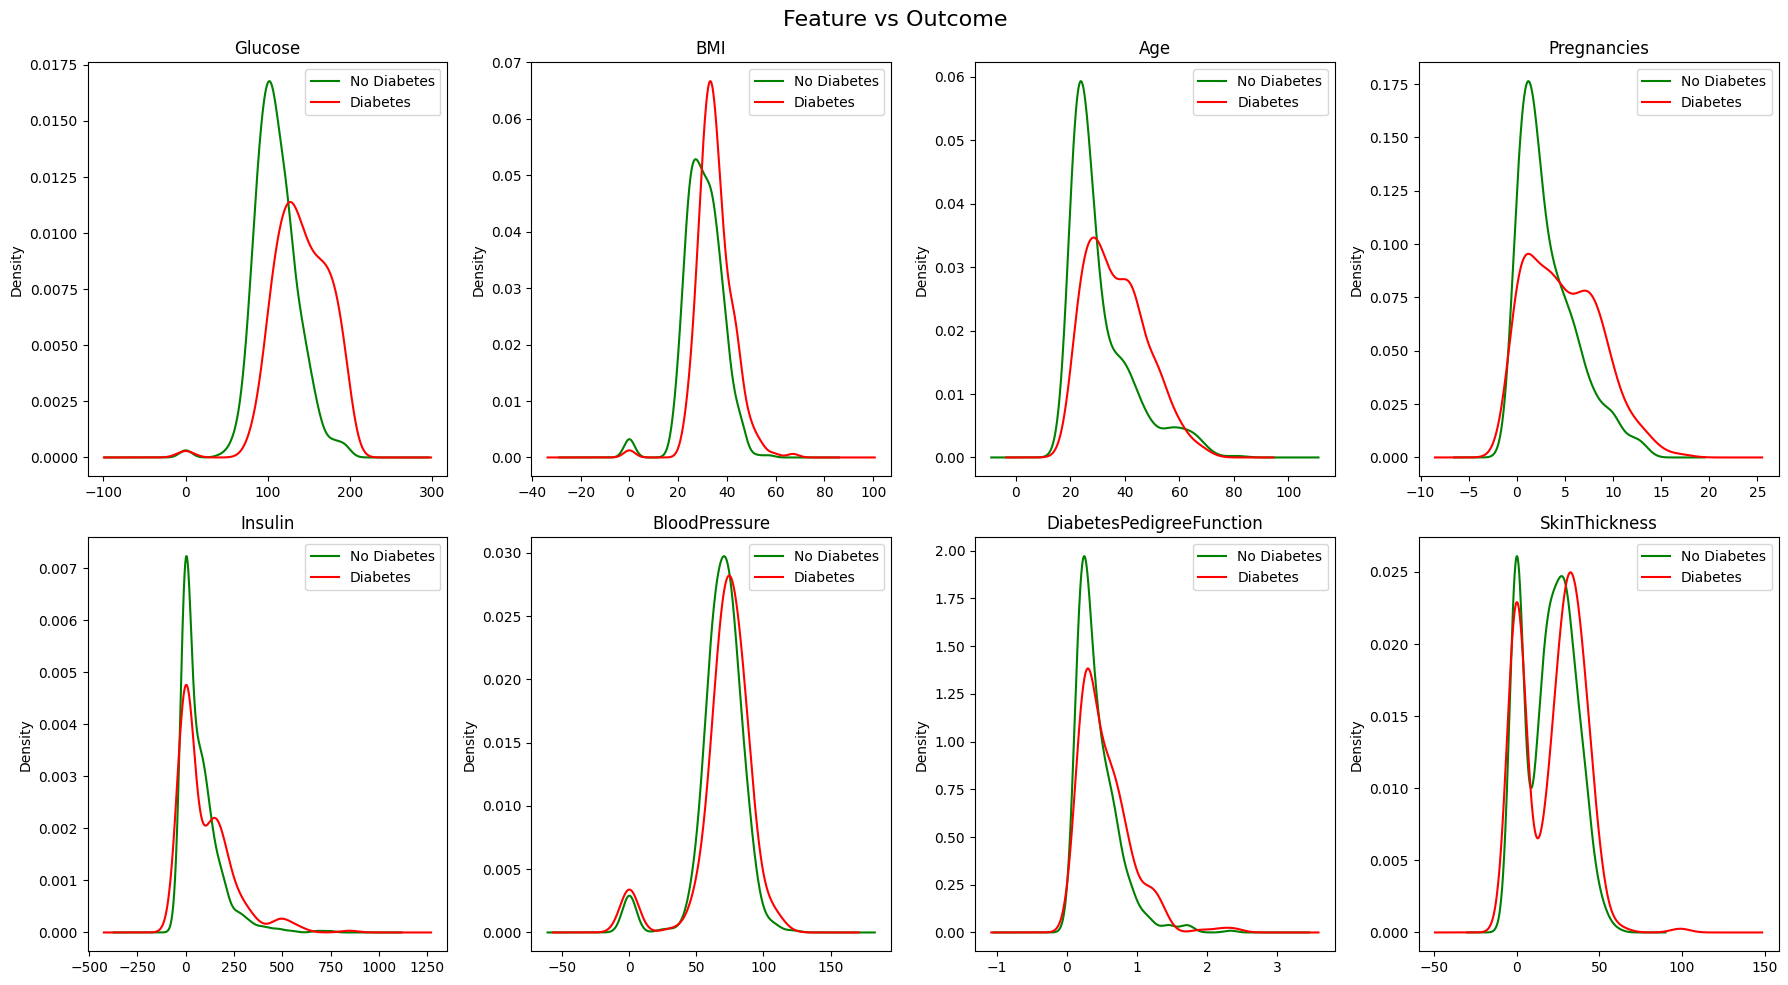

In [19]:
fig, axes = plt.subplots(2, 4, figsize=(18, 10))

features = ['Glucose', 'BMI', 'Age', 'Pregnancies',
            'Insulin', 'BloodPressure', 
            'DiabetesPedigreeFunction', 'SkinThickness']

for i, feature in enumerate(features):
    ax = axes[i//4, i%4]
    df[df['Outcome']==0][feature].plot(kind='kde', ax=ax,
                                label='No Diabetes', color='green')
    df[df['Outcome']==1][feature].plot(kind='kde', ax=ax,
                                label='Diabetes', color='red')
    ax.set_title(feature)
    ax.legend()

plt.suptitle('Feature vs Outcome', fontsize=16)
plt.tight_layout()
plt.show()

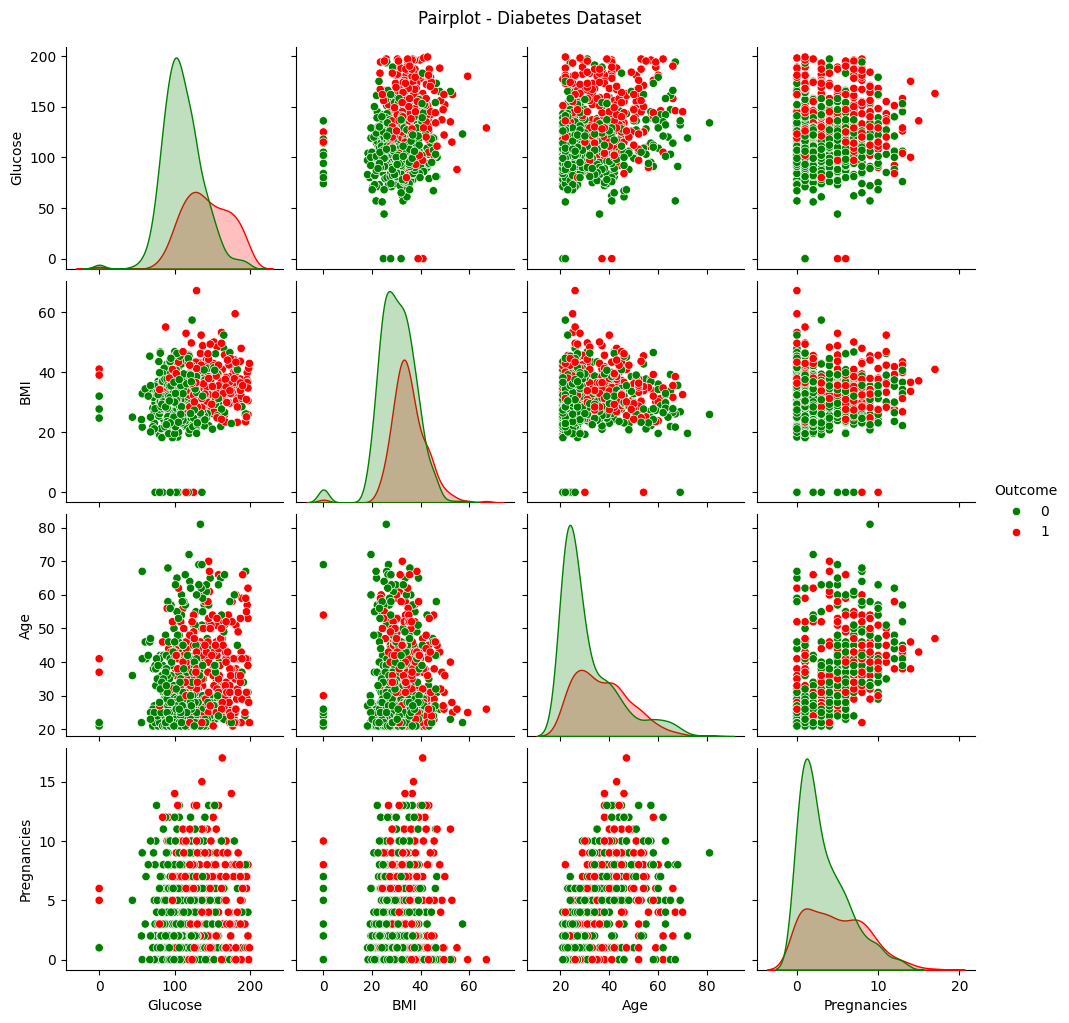

In [20]:
selected = ['Glucose', 'BMI', 
            'Age', 'Pregnancies', 'Outcome']

sns.pairplot(df[selected], hue='Outcome',
             palette={0:'green', 1:'red'},
             diag_kind='kde')

plt.suptitle('Pairplot - Diabetes Dataset', y=1.02)
plt.show()

In [21]:
# Columns with hidden zeros
zero_cols = ['Glucose', 'BloodPressure', 
             'SkinThickness', 'Insulin', 'BMI']

# Replace zeros with median
for col in zero_cols:
    median_val = df[col].median()
    df[col] = df[col].replace(0, median_val)
    print(f"{col} → zeros replaced with median: {median_val}")

Glucose → zeros replaced with median: 117.0
BloodPressure → zeros replaced with median: 72.0
SkinThickness → zeros replaced with median: 23.0
Insulin → zeros replaced with median: 30.5
BMI → zeros replaced with median: 32.0


In [22]:
print("Zeros remaining:")
for col in zero_cols:
    zeros = (df[col] == 0).sum()
    print(f"{col}: {zeros}")

Zeros remaining:
Glucose: 0
BloodPressure: 0
SkinThickness: 0
Insulin: 0
BMI: 0


In [23]:
X = df.drop('Outcome', axis=1)
y = df['Outcome']

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (768, 8)
y shape: (768,)


In [24]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

X_train: (614, 8)
X_test: (154, 8)


In [25]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)
print("Scaling complete!")



Scaling complete!


In [26]:
import joblib
joblib.dump(scaler, '../models/diabetes_scaler.pkl')
print("Diabetes scaler saved!")

Diabetes scaler saved!


In [27]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier 
from sklearn.metrics import accuracy_score,f1_score,roc_auc_score,confusion_matrix
import joblib , os

In [28]:
# Define models
models = {
    'Logistic Regression': LogisticRegression(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'SVM': SVC(probability=True, random_state=42),
    'XGBoost': XGBClassifier(random_state=42, 
                              eval_metric='logloss')
}

# Train and evaluate
results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:,1]
    
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)
    
    results[name] = {
        'Accuracy': round(acc*100, 2),
        'F1 Score': round(f1, 3),
        'ROC-AUC': round(auc, 3)
    }
    
    print(f"{name}:")
    print(f"  Accuracy : {acc*100:.2f}%")
    print(f"  F1 Score : {f1:.3f}")
    print(f"  ROC-AUC  : {auc:.3f}")
    print()

Logistic Regression:
  Accuracy : 76.62%
  F1 Score : 0.667
  ROC-AUC  : 0.820

Random Forest:
  Accuracy : 76.62%
  F1 Score : 0.679
  ROC-AUC  : 0.840

SVM:
  Accuracy : 75.32%
  F1 Score : 0.627
  ROC-AUC  : 0.808

XGBoost:
  Accuracy : 72.08%
  F1 Score : 0.626
  ROC-AUC  : 0.767



Best Model: Logistic Regression


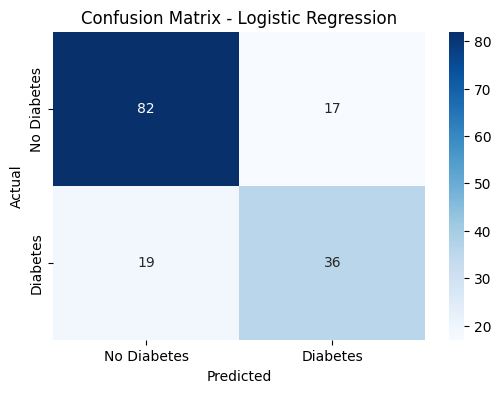

In [29]:
# After seeing results pick best model
# For now assuming Random Forest (usually wins diabetes)
best_name = max(results, key=lambda x: results[x]['Accuracy'])
print("Best Model:", best_name)

best_model = models[best_name]
y_pred_best = best_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Diabetes','Diabetes'],
            yticklabels=['No Diabetes','Diabetes'])
plt.title(f'Confusion Matrix - {best_name}')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

In [30]:
joblib.dump(best_model, '../models/diabetes_model.pkl')
print("✅ Diabetes model saved!")
print(os.listdir('../models'))

✅ Diabetes model saved!
['cancer_model.pkl', 'cancer_scaler.pkl', 'diabetes_model.pkl', 'diabetes_scaler.pkl', 'heart_model.pkl', 'heart_scaler.pkl']
